In [9]:
import importlib
import sys
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import geopandas as gpd

def load_world():
    """
    Load Natural Earth country borders.
    geopandas < 1.0  → bundled naturalearth_lowres
    geopandas >= 1.0 → bundled dataset removed; use geodatasets or direct URL
    """
    try:
        # geopandas < 1.0
        return gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
    except AttributeError:
        pass
 
    try:
        # geopandas >= 1.0 with geodatasets installed
        from geodatasets import get_path
        return gpd.read_file(get_path("naturalearth.land"))
    except Exception:
        pass
 
    # Universal fallback: download directly from Natural Earth
    url = (
        "https://naciscdn.org/naturalearth/110m/cultural/"
        "ne_110m_admin_0_countries.zip"
    )
    print(f"Downloading Natural Earth borders from {url} ...")
    return gpd.read_file(url)

In [10]:

# -- Load --------------------------------------------------------------------
df = pd.read_csv(r"C:\Users\darja\Complexity72h\complexity72_2026\clustering\co-occurrence-clusters.csv")

COMPONENT_COLS = [c for c in df.columns if c.startswith("component_")]
N_CLUSTERS = len(COMPONENT_COLS)

# -- Melt to long format: one row per (lat, lon, time, cluster_id) ----------
df_long = df.melt(
    id_vars=["lat", "lon", "time", "emission", "gosif"],
    value_vars=COMPONENT_COLS,
    var_name="component",
    value_name="member",
)
# Keep only rows where the point belongs to the cluster
df_long = df_long[df_long["member"] == 1].copy()
df_long["cluster_id"] = df_long["component"].str.extract(r"(\d+)$").astype(int)

# -- Build cluster dominance map BEFORE mapping to points --------------------
cluster_stats = (
    df_long.groupby("cluster_id")[["emission", "gosif"]]
    .mean()
    .reset_index()
)

cluster_null_mask = (cluster_stats["emission"] == 0.0) & (cluster_stats["gosif"] == 0.0)
active = cluster_stats[~cluster_null_mask]

def safe_minmax(series, xmin, xmax):
    if xmax == xmin:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - xmin) / (xmax - xmin)

if active.empty:
    cluster_stats["emission_norm"] = 0.0
    cluster_stats["gosif_norm"] = 0.0
else:
    e_min, e_max = active["emission"].min(), active["emission"].max()
    g_min, g_max = active["gosif"].min(), active["gosif"].max()

    cluster_stats["emission_norm"] = safe_minmax(cluster_stats["emission"], e_min, e_max)
    cluster_stats["gosif_norm"] = safe_minmax(cluster_stats["gosif"], g_min, g_max)

# Dominance: +1 -> fully emission-dominated, -1 -> fully gosif-dominated
# Null clusters get NaN -> rendered as gray via cmap.set_bad()
cluster_stats["dominance"] = cluster_stats["emission_norm"] - cluster_stats["gosif_norm"]
cluster_stats.loc[cluster_null_mask, "dominance"] = np.nan

dom_map = dict(zip(cluster_stats["cluster_id"], cluster_stats["dominance"]))

# -- One row per unique lat-lon ----------------------------------------------
point_cluster = (
    df_long.groupby(["lat", "lon"])["cluster_id"]
    .first()
    .reset_index()
)
point_cluster["dominance"] = point_cluster["cluster_id"].map(dom_map)

# -- Load and Process Transitional Data (Sophia) ------------------------------
df2 = pd.read_csv(r"C:/Users/darja/Complexity72h/complexity72_2026/clustering/sophia.csv")
df2.drop(columns=["component_1", "component_2", "component_3", "component_4", "component_5"], inplace=True)

COMPONENT_COLS = [c for c in df2.columns if c.startswith("component_")]

# Melt to long format and keep active assignments
df2_long = df2.melt(
    id_vars=["lat", "lon", "time", "emission", "gosif"],
    value_vars=COMPONENT_COLS,
    var_name="component",
    value_name="member",
)
df2_long = df2_long[df2_long["member"] == 1].copy()
df2_long["cluster_id"] = df2_long["component"].str.extract(r"(\d+)$").astype(int)
 
# Get unique lat-lon rows for transitional points
point_cluster2 = (
    df2_long.groupby(["lat", "lon"])["cluster_id"]
    .first()
    .reset_index()
)



Location-to-cluster matches (nearest dataset points):
  - Beijing: C4 at (116.50, 39.50), distance=0.41°
  - Ruhr Valley: C4 at (7.50, 51.50), distance=0.21°
  - Tokyo: C4 at (139.50, 35.50), distance=0.23°
  - Los Angeles: C3 at (-117.50, 35.50), distance=1.63°
  - Amazon: C5 at (-62.50, -3.50), distance=0.48°
  - Borneo: C5 at (113.50, 0.50), distance=0.50°
  - Patagonia: C2 at (-71.50, -47.50), distance=0.71°
  - Siberia: C2 at (104.50, 59.50), distance=0.71°
  - Australian Outback: C3 at (132.50, -24.50), distance=0.71°
Saved: cluster_map_transitional_cities.png with matched location cluster colors


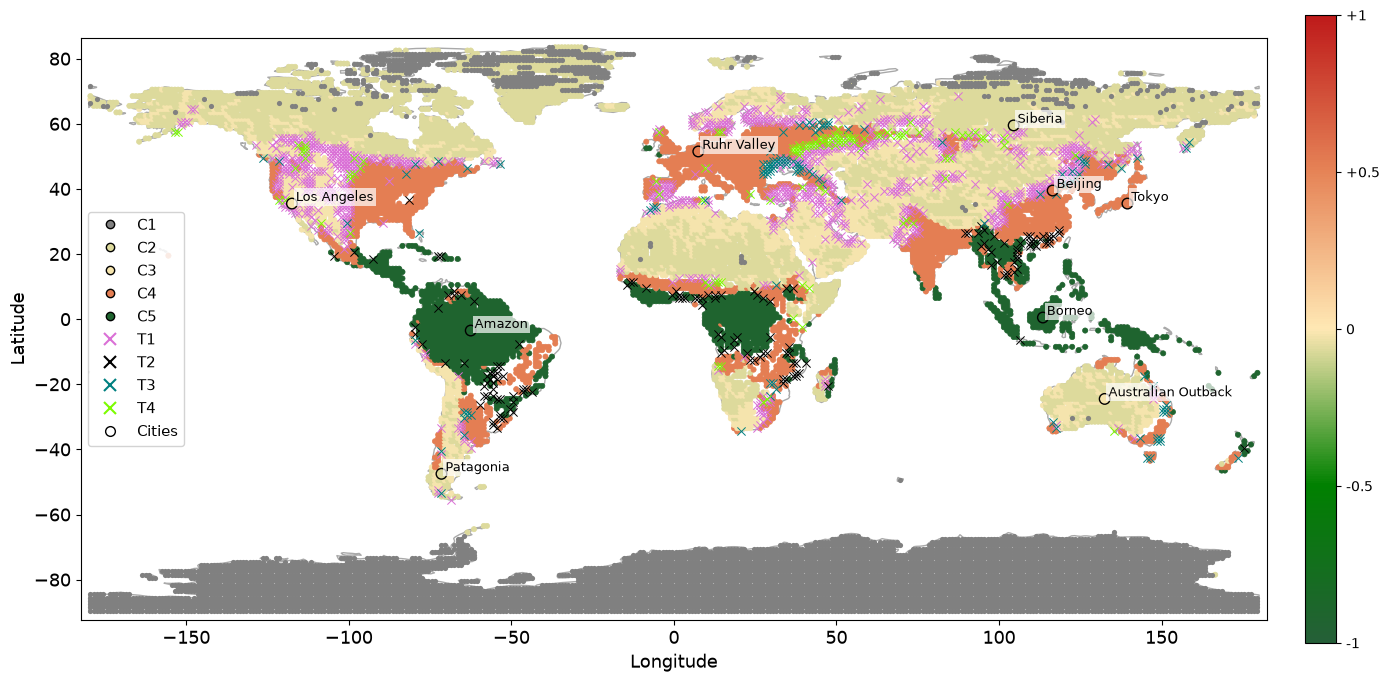

In [11]:
# -- Base Map Configuration (Muted Diverging) ---------------------------------
NULL_GRAY = "gray"
colors_muted = ["#255F38", "green", "#FFE8B4", "#E68457", "#BE1A1A"]
cmap = mcolors.LinearSegmentedColormap.from_list("muted_div", colors_muted)
cmap.set_bad(color=NULL_GRAY)
norm = mcolors.Normalize(vmin=-1, vmax=1)

# Force re-execution by re-running the full map cell
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_facecolor("white")
world = load_world()
world.plot(
    ax=ax,
    facecolor="white",
    edgecolor="darkgray",
    linewidth=1,
    zorder=1,
)

# -- BASE LAYER: BACKGROUND DOMINANCE CLUSTERS -------------------------------
cluster1_mask = point_cluster["cluster_id"] == 1
valid_mask = point_cluster["dominance"].notna() & (~cluster1_mask)
other_null_mask = point_cluster["dominance"].isna() & (~cluster1_mask)

# 1. Plot background valid points (C1 explicitly excluded)
sc = ax.scatter(
    point_cluster.loc[valid_mask, "lon"], 
    point_cluster.loc[valid_mask, "lat"],
    c=point_cluster.loc[valid_mask, "dominance"],
    cmap=cmap, norm=norm,
    s=14, alpha=1,
    zorder=2, linewidths=0.5, 
)

# 2. Plot non-C1 null points in gray
if other_null_mask.any():
    ax.scatter(
        point_cluster.loc[other_null_mask, "lon"], 
        point_cluster.loc[other_null_mask, "lat"],
        color=NULL_GRAY,
        s=12, alpha=0.85,
        zorder=3, linewidths=0,
    )

# 3. Plot C1 last, in gray, so it always stays gray on top of background colors
if cluster1_mask.any():
    ax.scatter(
        point_cluster.loc[cluster1_mask, "lon"],
        point_cluster.loc[cluster1_mask, "lat"],
        color=NULL_GRAY,
        s=14, alpha=1.0,
        zorder=4, linewidths=0,
    )

# Build explicit SC legend handles so background cluster labels always render
background_handles = []
for c_id in sorted(point_cluster["cluster_id"].dropna().unique()):
    if int(c_id) == 1:
        face = NULL_GRAY
    else:
        dom_val = dom_map.get(c_id, np.nan)
        face = NULL_GRAY if pd.isna(dom_val) else cmap(norm(dom_val))

    background_handles.append(
        plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markerfacecolor=face,
            markeredgecolor="black",
            markersize=6,
            label=f"C{int(c_id)}",
        )
    )

# -- TOP LAYER: TRANSITIONAL REGIONS OVERLAY (HIGH-CONTRAST STARS) -----------
unique_trans_clusters = sorted(point_cluster2["cluster_id"].dropna().unique())
custom_trans_colors = ['orchid', 'black', 'teal', 'lawngreen']

# List to gather custom legend entries
legend_handles = []

# Loop using an explicit index counter (1, 2, 3, 4) to label them T1 through T4
for idx, c_id in enumerate(unique_trans_clusters, start=1):
    cluster_mask = point_cluster2["cluster_id"] == c_id
    
    # Cycle safely through your custom list of colors
    trans_color = custom_trans_colors[(idx - 1) % len(custom_trans_colors)]
    
    if mcolors.to_hex(trans_color) == "#ff7f0e":
        trans_color = "purple"
    
    if cluster_mask.any():
        ax.scatter(
            point_cluster2.loc[cluster_mask, "lon"], 
            point_cluster2.loc[cluster_mask, "lat"],
            color=trans_color,
            marker="x",
            s=35,               
            alpha=1.0,
            zorder=5,           
            linewidths=0.7,
)
        
        # Append a corresponding true-color 'x' marker to the legend handles array
        legend_handles.append(
            plt.Line2D(
                [0], [0], 
                marker='x', 
                linestyle='None',
                markerfacecolor='none',
                markeredgecolor=trans_color,
                markersize=8, 
                markeredgewidth=1.5, 
                label=f"T{idx}"
            )
        )

# -- CITY / REGION OVERLAY MATCHED TO CLUSTER DATASET -------------------------
target_locations = [
    ("Beijing", 116.4074, 39.9042),
    ("Ruhr Valley", 7.3000, 51.4500),
    ("Tokyo", 139.6503, 35.6762),
    ("Los Angeles", -118.2437, 34.0522),
    ("Amazon", -62.2159, -3.1190),
    ("Borneo", 114.0000, 0.5000),
    ("Patagonia", -71.0000, -47.0000),
    ("Siberia", 105.0000, 60.0000),
    ("Australian Outback", 133.0000, -24.0000),
]

cluster_points = point_cluster[["lon", "lat", "cluster_id"]].dropna().copy()

def nearest_cluster_point(lon, lat):
    d2 = (cluster_points["lon"] - lon) ** 2 + (cluster_points["lat"] - lat) ** 2
    idx = d2.idxmin()
    row = cluster_points.loc[idx]
    return int(row["cluster_id"]), float(row["lon"]), float(row["lat"]), float(np.sqrt(d2.loc[idx]))

location_matches = []
for name, lon, lat in target_locations:
    c_id, lon_m, lat_m, dist = nearest_cluster_point(lon, lat)
    if c_id == 1:
        color = NULL_GRAY
    else:
        dom_val = dom_map.get(c_id, np.nan)
        color = NULL_GRAY if pd.isna(dom_val) else cmap(norm(dom_val))

    location_matches.append(
        {
            "name": name,
            "cluster_id": c_id,
            "lon": lon_m,
            "lat": lat_m,
            "distance_deg": dist,
            "color": color,
        }
    )

match_lons = [m["lon"] for m in location_matches]
match_lats = [m["lat"] for m in location_matches]
match_colors = [m["color"] for m in location_matches]

ax.scatter(
    match_lons,
    match_lats,
    marker="o",
    s=58,
    c=match_colors,
    edgecolors="black",
    linewidths=1.0,
    zorder=6,
    alpha=1.0,
)

for m in location_matches:
    ax.text(
        m["lon"] + 1.2,
        m["lat"] + 0.8,
        f"{m['name']}",
        fontsize=9,
        color="black",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5),
        zorder=7,
    )

print("Location-to-cluster matches (nearest dataset points):")
for m in location_matches:
    print(
        f"  - {m['name']}: C{m['cluster_id']} at "
        f"({m['lon']:.2f}, {m['lat']:.2f}), distance={m['distance_deg']:.2f}°"
    )

matched_handle = plt.Line2D(
    [0], [0],
    marker="o",
    linestyle="None",
    markerfacecolor="white",
    markeredgecolor="black",
    markersize=7,
    label="Cities",
)

# -- Colorbar and Layout Aesthetics -------------------------------------------
cbar = plt.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax, orientation="vertical", fraction=0.025, pad=0.03,
)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.set_ticklabels(["-1", "-0.5", "0", "+0.5", "+1"])

# Render legend showing SC, transitional markers, and matched locations
all_handles = background_handles + legend_handles + [matched_handle]
ax.legend(handles=all_handles, loc="center left", fontsize=11, framealpha=0.85)

# Fallback extent so this cell can run standalone if bounds are not pre-defined
if not all(k in globals() for k in ["lon_min", "lon_max", "lat_min", "lat_max"]):
    pad = 3
    lon_min = point_cluster["lon"].min() - pad
    lon_max = point_cluster["lon"].max() + pad
    lat_min = point_cluster["lat"].min() - pad
    lat_max = point_cluster["lat"].max() + pad

ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.set_xlabel("Longitude", fontsize=13)
ax.set_ylabel("Latitude",  fontsize=13)
ax.tick_params(labelsize=13)

plt.tight_layout()
#plt.savefig("cluster_map_transitional_cities.png", dpi=150, bbox_inches="tight")
print("Saved: cluster_map_transitional_cities.png with matched location cluster colors")
plt.show()